# Final Corpus Classification — GPT-5.4-mini (v5)

Batch classification of the final corpus using a single API call per corpus type to minimise token usage.

> **Note:** The standard / irony / obfuscated splits share identical test sets within each corpus type. Classification is therefore run once per corpus type (raw-corpus and pre-filtered-corpus).

## Dependencies

In [1]:
import os
import re

from openai import OpenAI

import pandas as pd

from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

import watermark

%load_ext watermark
%matplotlib inline

plt.style.use('../style.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
%watermark -n -v -m -iv

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.4.0

Compiler    : Clang 16.0.0 (clang-1600.0.26.6)
OS          : Darwin
Release     : 25.5.0
Machine     : x86_64
Processor   : i386
CPU cores   : 8
Architecture: 64bit

matplotlib: 3.10.5
openai    : 1.99.6
watermark : 2.5.0
sklearn   : 1.7.1
re        : 2.2.1
pandas    : 2.3.1
seaborn   : 0.13.2



## OpenAI client

In [3]:
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

## Batch classifier

Sends **all tweets in a single API call**. The response is a numbered list (`1. POSITIVE`, `2. NEGATIVE`, …) that is parsed back to a Series.

In [4]:
SYSTEM_MSG = "Sos un clasificador binario de tweets que hablan sobre drogas ilícitas"

CRITERIA = """\
    Clasifica cada tweet como POSITIVE o NEGATIVE aplicando esta jerarquía de reglas:

    1. Si el autor afirma explícitamente que consume, ha consumido o desea consumir drogas ilícitas, y lo expresa de manera neutral o positiva → POSITIVE.
    2. Si el autor menciona consumo propio pero con desaprobación, crítica o rechazo → NEGATIVE.
    3. Si describe consumo de otra persona, real o ficticia → NEGATIVE.
    4. Si es ambiguo y puede interpretarse de forma no problemática → NEGATIVE.
    5. Si menciona drogas ilícitas en contextos humorísticos, ficticios, metafóricos o musicales, sin expresar deseo o nostalgia propia → NEGATIVE.
    6. Si menciona "tomar una línea" en contexto de transporte público → NEGATIVE.

    Definiciones:
    - "Neutral o positiva" significa que el autor no expresa desaprobación o condena.
    - "Nostalgia" implica recordar consumo pasado con añoranza o valoración positiva."""

def build_batch_prompt(tweets: list[str]) -> str:
    numbered = "\n".join(f"{i+1}. {t}" for i, t in enumerate(tweets))
    return (
        CRITERIA
        + "\n\n"
        + "Responde con una lista numerada, exactamente una clasificación por línea, "
        + "únicamente la palabra POSITIVE o NEGATIVE (sin puntuación adicional ni explicaciones):\n\n"
        + numbered
    )

def parse_batch_response(response_text: str, n: int) -> list[str]:
    lines = [l.strip() for l in response_text.strip().splitlines() if l.strip()]
    results = []
    for line in lines:
        # strip optional leading "N." or "N)"
        cleaned = re.sub(r"^\d+[.)\s]+", "", line).strip().upper().rstrip(".")
        if cleaned in ("POSITIVE", "NEGATIVE"):
            results.append(cleaned)
    if len(results) != n:
        raise ValueError(f"Expected {n} classifications, got {len(results)}. Response:\n{response_text}")
    return results

def classify_batch(tweets: list[str]) -> list[str]:
    prompt = build_batch_prompt(tweets)
    response = client.chat.completions.create(
        model="gpt-5.4-mini",
        messages=[
            {"role": "system", "content": SYSTEM_MSG},
            {"role": "user", "content": prompt},
        ],
        temperature=1,
    )
    return parse_batch_response(response.choices[0].message.content, len(tweets))

## Corpus types

Each entry is `(label, path_to_test_csv, output_prefix)`.

In [5]:
CORPORA = [
    ("raw-corpus",           "../data/raw/final-corpus/raw-corpus/standard/test.csv",           f"raw-corpus_v5"),
    ("pre-filtered-corpus",  "../data/raw/final-corpus/pre-filtered-corpus/standard/test.csv",  f"pre-filtered-corpus_v5"),
]


## Run batch classification

In [6]:
results = {}

for corpus_label, csv_path, out_prefix in CORPORA:
    print(f"\n{'='*60}")
    print(f"Corpus: {corpus_label}")
    print(f"{'='*60}")

    df = pd.read_csv(csv_path)
    tweets = df["text"].tolist()
    labels = df["label"].tolist()

    print(f"Tweets to classify: {len(tweets)}")

    predictions = classify_batch(tweets)
    df["prediction"] = predictions

    results[corpus_label] = df
    print(f"Done. Predictions: {df['prediction'].value_counts().to_dict()}")


Corpus: raw-corpus
Tweets to classify: 450


Done. Predictions: {'NEGATIVE': 294, 'POSITIVE': 156}

Corpus: pre-filtered-corpus
Tweets to classify: 450


Done. Predictions: {'NEGATIVE': 271, 'POSITIVE': 179}


## Metrics per corpus


Corpus: raw-corpus


/var/folders/d7/53rh3m0d4j983v3p54wjrlf80000gn/T/ipykernel_60254/3249787319.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


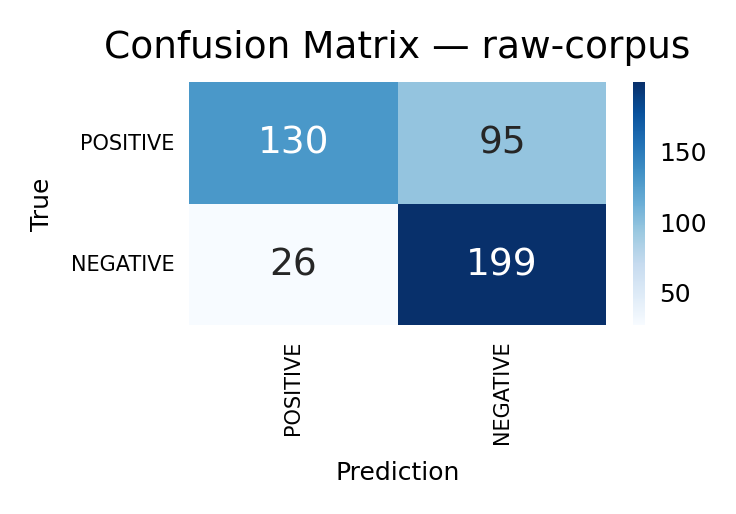

[[130  95]
 [ 26 199]]

Classification report:


,precision,recall,f1-score,support
POSITIVE,0.83,0.58,0.68,225
NEGATIVE,0.68,0.88,0.77,225
accuracy,0.73,0.73,0.73,1
macro avg,0.76,0.73,0.72,450
weighted avg,0.76,0.73,0.72,450



Wrongly classified: 121


,text,label,prediction
2,me quiero tomar una línea tan larga que tenga ...,POSITIVE,NEGATIVE
7,Mi mamá me pidió que piense en mi futuro y aba...,NEGATIVE,POSITIVE
11,Yo elegí inyectarme heroína pero nunca elegí s...,POSITIVE,NEGATIVE
12,Arranque carmel e inyectarme heroina era más s...,NEGATIVE,POSITIVE
13,Me fumo un porro y me sale el chef de adentro,POSITIVE,NEGATIVE
...,...,...,...
426,O voy a tomar y inyectarme heroina y jalar coc...,POSITIVE,NEGATIVE
430,Estoy jugando a un juego que me incentiva a in...,NEGATIVE,POSITIVE
438,"Voy a tener que empezar a tomar merca, no pued...",NEGATIVE,POSITIVE
448,#PorVos dejo de inyectarme heroína,POSITIVE,NEGATIVE



Corpus: pre-filtered-corpus


/var/folders/d7/53rh3m0d4j983v3p54wjrlf80000gn/T/ipykernel_60254/3249787319.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


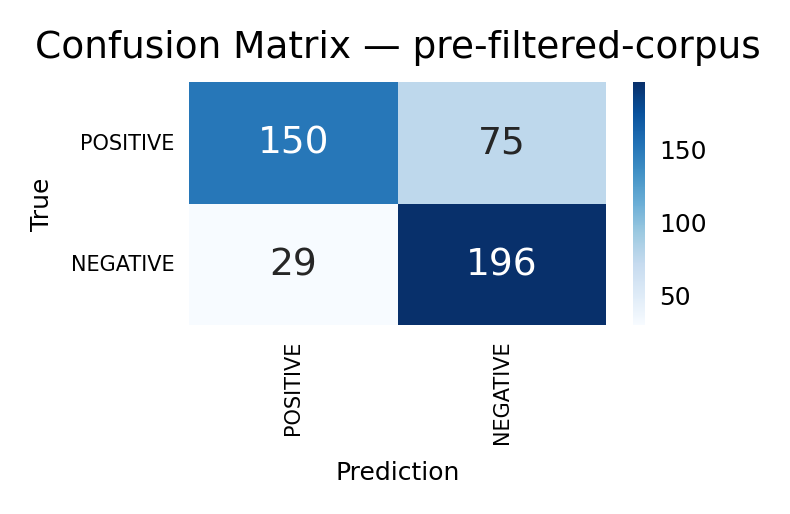

[[150  75]
 [ 29 196]]

Classification report:


,precision,recall,f1-score,support
POSITIVE,0.84,0.67,0.74,225
NEGATIVE,0.72,0.87,0.79,225
accuracy,0.77,0.77,0.77,1
macro avg,0.78,0.77,0.77,450
weighted avg,0.78,0.77,0.77,450



Wrongly classified: 104


,text,label,prediction
0,me voy a tomar una línea así quedo bien dura😝,POSITIVE,NEGATIVE
2,Voy a hacer una crónica de inyectarme heroína ...,POSITIVE,NEGATIVE
5,Me voy a tomar una raya de merca cada vez que ...,POSITIVE,NEGATIVE
13,"""si queres vamos a fumar unas florcitas y toma...",POSITIVE,NEGATIVE
15,"Que feo es salir por Lanús, te queres tomar un...",POSITIVE,NEGATIVE
...,...,...,...
436,El inglés es muy de tomar merca cada 3-4 meses,NEGATIVE,POSITIVE
440,Me voy a fumar un porro que va a tener que ven...,POSITIVE,NEGATIVE
441,storytime ayer casi quemo mi casa a las 3 de l...,POSITIVE,NEGATIVE
445,me he fumado un porro antes de salir de la cam...,POSITIVE,NEGATIVE


In [7]:
LABELS = ["POSITIVE", "NEGATIVE"]

for corpus_label, _, out_prefix in CORPORA:
    df = results[corpus_label]
    y_true = df["label"]
    y_pred = df["prediction"]

    print(f"\n{'='*60}")
    print(f"Corpus: {corpus_label}")
    print(f"{'='*60}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    fig, ax = plt.subplots(figsize=(2, 1))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS,
                cbar=True, annot_kws={"size": 9}, ax=ax)
    ax.collections[0].colorbar.ax.tick_params(labelsize=6)
    ax.set_xlabel("Prediction", fontsize=6)
    ax.set_ylabel("True", fontsize=6)
    ax.tick_params(labelsize=5)
    ax.set_title(f"Confusion Matrix — {corpus_label}", fontsize=9)
    plt.tight_layout()
    plt.show()
    print(cm)

    # Classification report
    report = classification_report(y_true, y_pred, labels=LABELS, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    print("\nClassification report:")
    display(report_df.style.format({"precision": "{:.2f}", "recall": "{:.2f}", "f1-score": "{:.2f}", "support": "{:.0f}"}))

    # Errors
    df["error"] = df["label"] != df["prediction"]
    errors = df[df["error"]][["text", "label", "prediction"]]
    print(f"\nWrongly classified: {len(errors)}")
    display(errors)

## Save wrongly-classified tweets

In [8]:
for corpus_label, _, out_prefix in CORPORA:
    df = results[corpus_label]
    errors = df[df["label"] != df["prediction"]][["text", "label", "prediction"]]
    out_path = f"../data/processed/final-corpus/{corpus_label}/wct_gpt-5.4-mini-v5.csv"
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    errors.to_csv(out_path, index=False)
    print(f"Saved {len(errors)} errors → {out_path}")

Saved 121 errors → ../data/processed/final-corpus/raw-corpus/wct_gpt-5.4-mini-v5.csv
Saved 104 errors → ../data/processed/final-corpus/pre-filtered-corpus/wct_gpt-5.4-mini-v5.csv
